In [53]:
import os

os.chdir("/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6")
print(os.getcwd())

/home/aadityasharma/Desktop/Aaditya_Sharma_Trainee_Hestabit/Week_6


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np

print("Libraries Imported")

Libraries Imported


In [55]:
DATA_PATH = "src/data/processed/diabetes_clean.csv"
LOG_DIR = "src/logs"

os.makedirs(LOG_DIR, exist_ok=True)

print("Data Path", DATA_PATH)
print("Log Directory",LOG_DIR)

Data Path src/data/processed/diabetes_clean.csv
Log Directory src/logs


In [56]:
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

print("Loaded Cleaned Data")

Dataset Shape: (768, 7)
Loaded Cleaned Data


In [57]:
print("Dataset information")

df.info()

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    float64
 6   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 42.1 KB


In [58]:
cols = df.columns.difference(['Outcome','Pregnancies'])   # all columns except Outcome
df[cols] = df[cols].replace(0, np.nan)

In [59]:
print("Missing values summary")
df.isnull().sum()

Missing values summary


Pregnancies                 0
Glucose                     0
BloodPressure               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [60]:
print("Statistical Summary")
df.describe()

Statistical Summary


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.656250,72.358073,32.393359,0.458914,33.199870,0.348958
std,3.344157,30.438286,11.697097,6.667471,0.285596,11.628404,0.476951
min,0.000000,44.000000,40.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,104.000000,50.250000,1.200000,66.500000,1.000000


Missing values heatmap


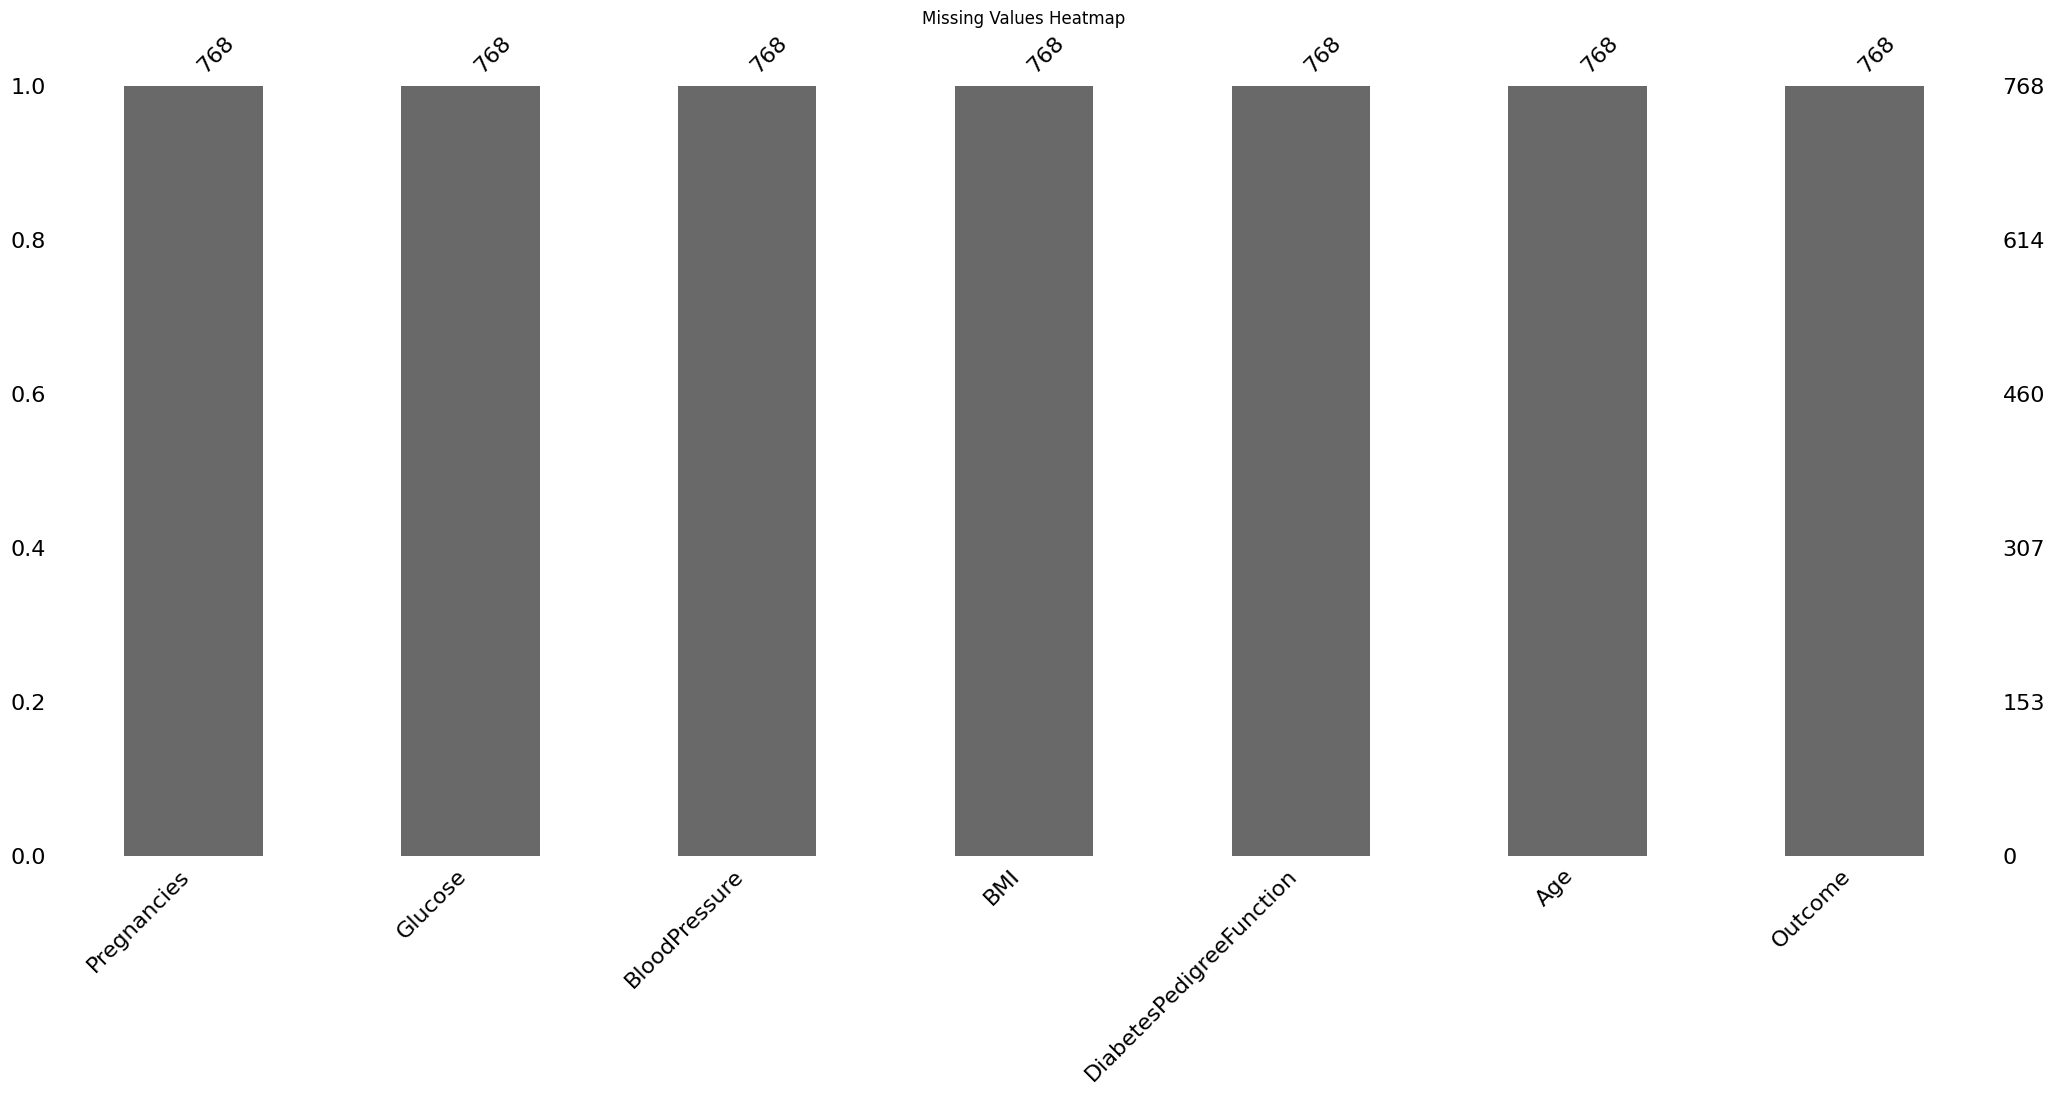

In [61]:
print("Missing values heatmap")

plt.figure(figsize=(1,1))
msno.bar(df)
plt.title("Missing Values Heatmap")

plt.savefig(f"{LOG_DIR}/missing_values_heatmap.png")
plt.show()

Correlation Matrix


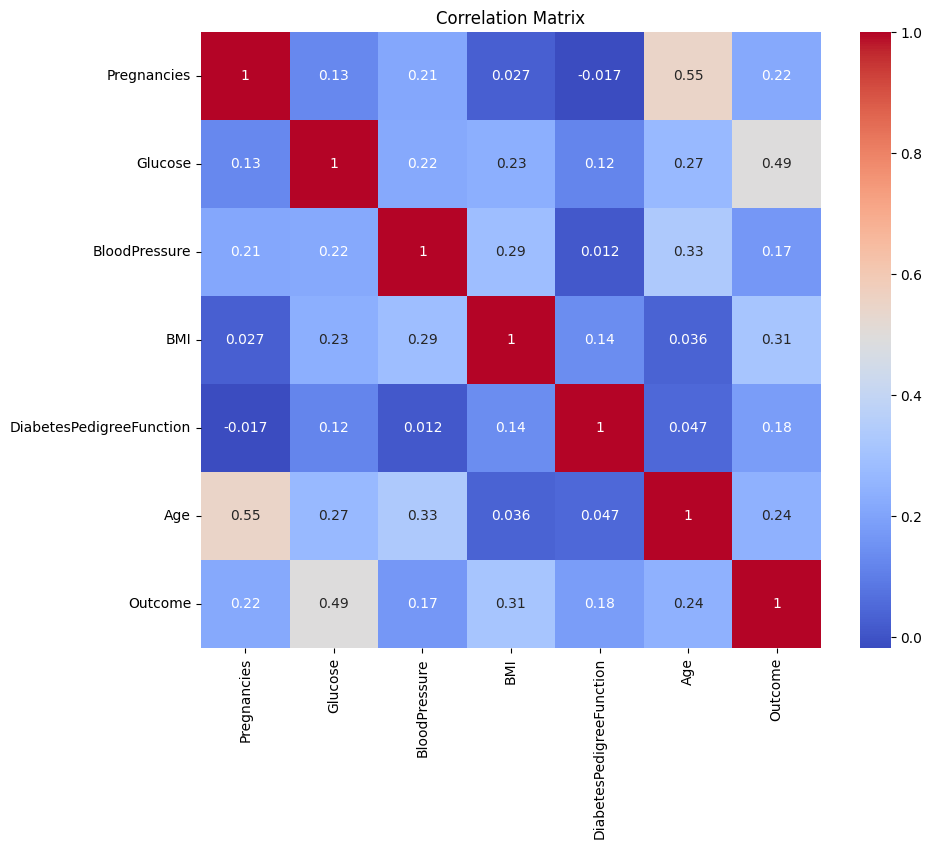

In [62]:
print("Correlation Matrix")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig(f"{LOG_DIR}/correlation_matrix.png")
plt.show()

Target Distribution


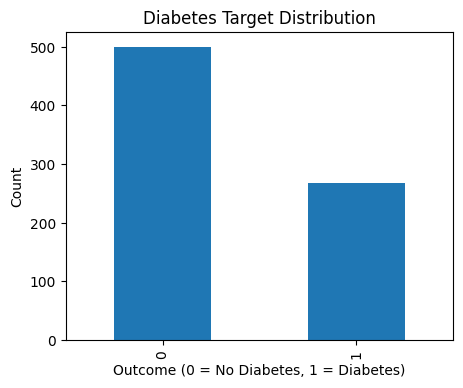

In [63]:

print("Target Distribution")
plt.figure(figsize=(5,4))

df["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Target Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")

plt.savefig(f"{LOG_DIR}/target_distribution.png")
plt.show()

Feature Distributions


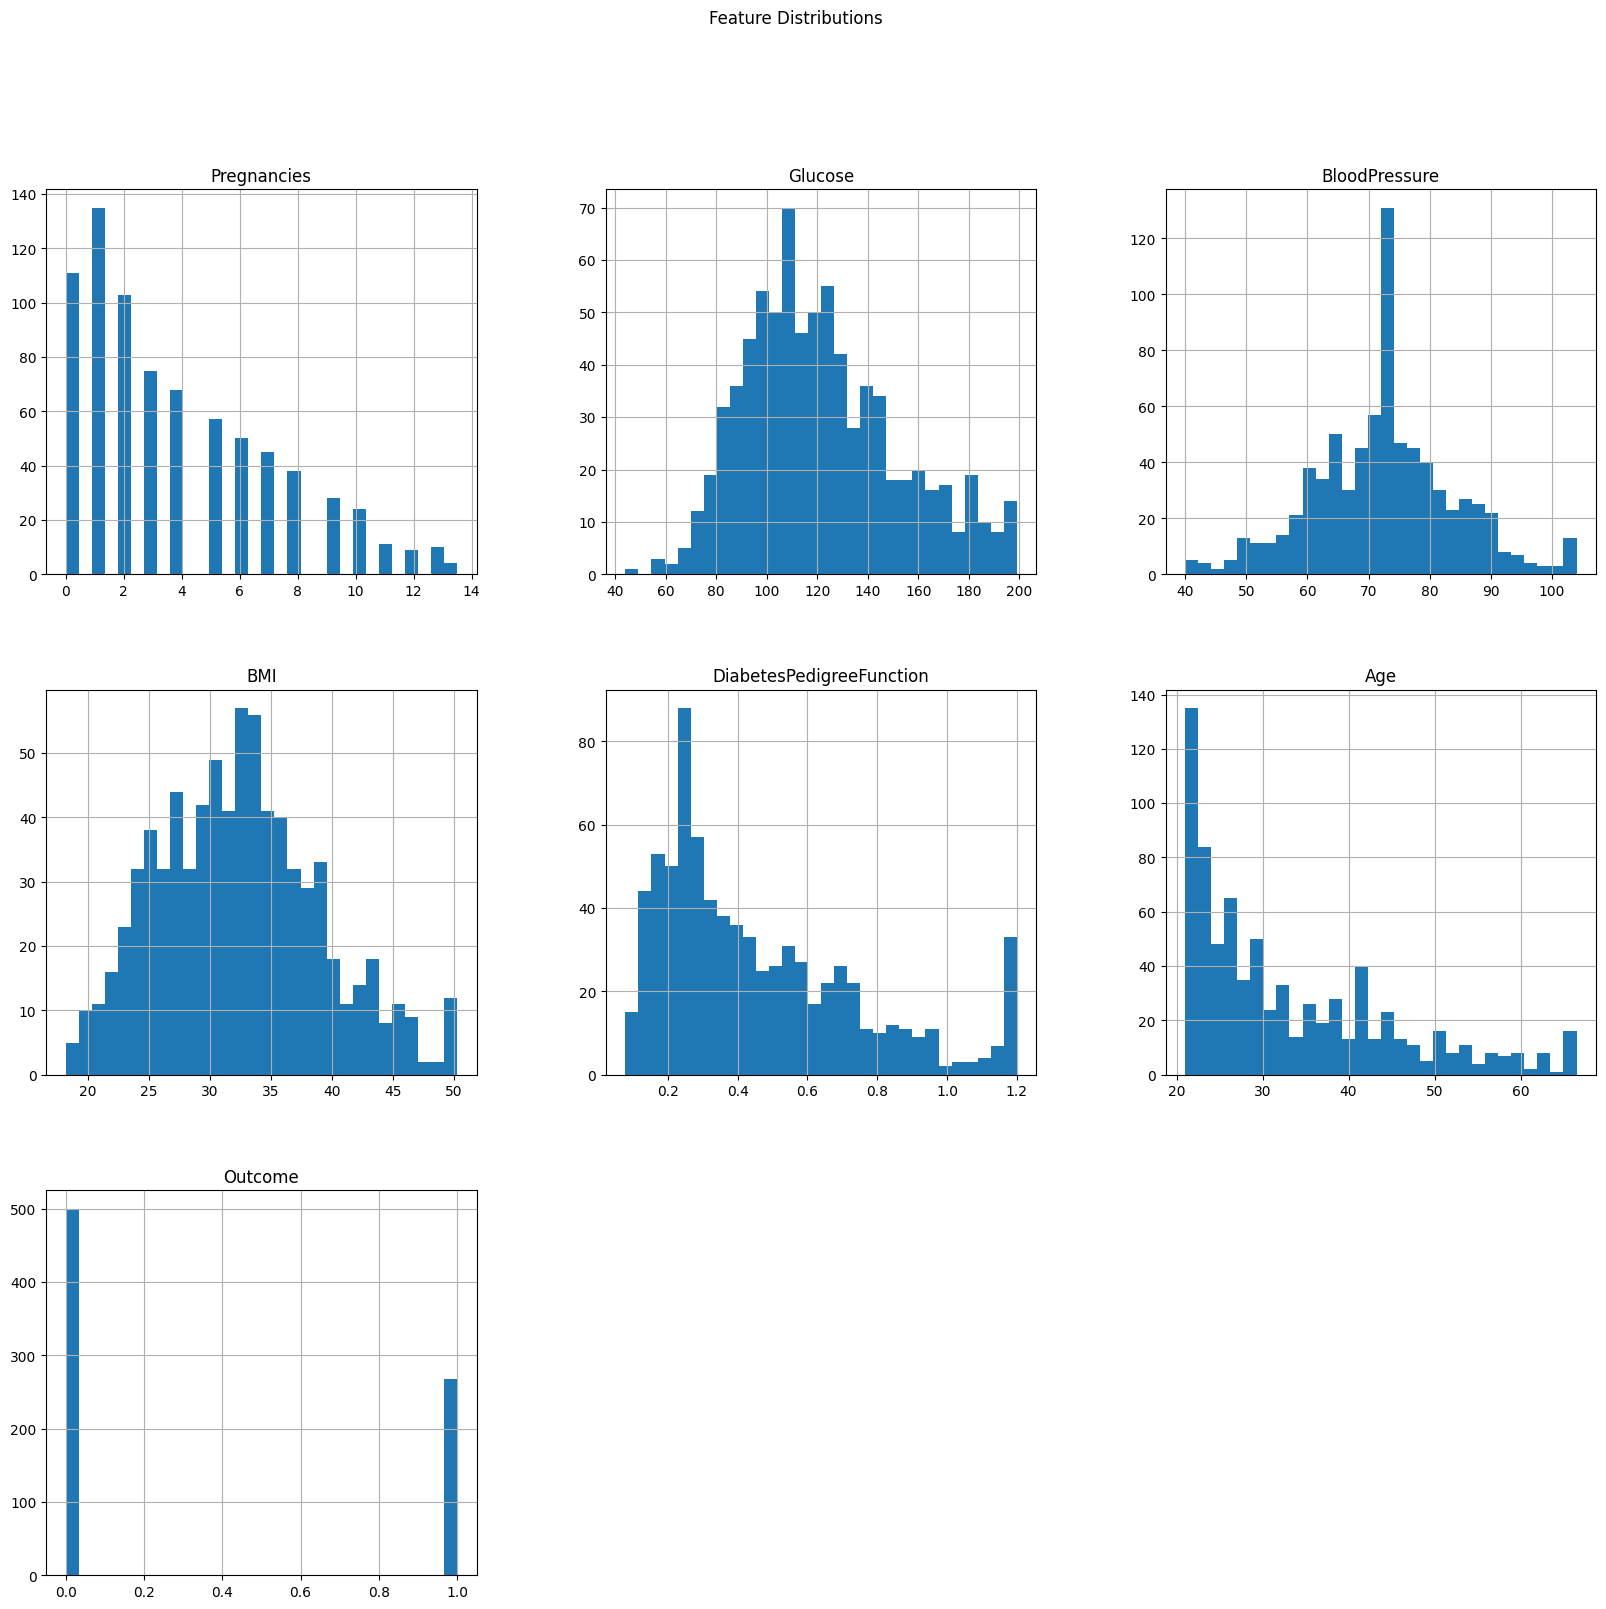

In [64]:
print("Feature Distributions")

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(figsize=(20,18), bins=30)

plt.suptitle("Feature Distributions")

plt.savefig(f"{LOG_DIR}/feature_distributions.png")
plt.show()

<Axes: >

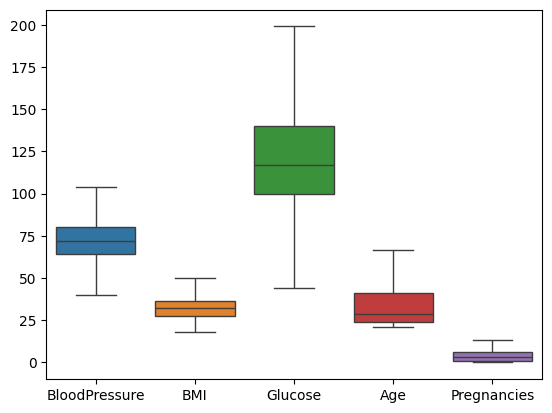

In [ ]:
sns.boxplot(data=df[['BloodPressure','BMI','Glucose','Age','Pregnancies']])